## Gold Comparison & Evaluation (Deliverable 1.3.4)

This notebook performs the final comparison between the baseline model and the three-stage cascade. It evaluates whether the cascade meaningfully improves alert quality by reducing false positives and noisy alerts while preserving useful anomaly sensitivity.

**Purpose:**  
To combine the alert outputs from the Baseline Modeling and Cascade Modeling notebooks, compute evaluation metrics, perform paired statistical testing, and generate the comparative visualizations required for Section C.

**Key Goals:**

- Load baseline and cascade alert outputs.
- Align alerts into comparable time windows for paired evaluation.
- Compute alert-volume metrics, false-positive rates, normal-period alerts, and anomaly responsiveness.
- Perform the planned statistical significance test (paired/Wilcoxon) to quantify model differences.
- Produce comparison tables, charts, and anomaly overlays for Section C.6.
- Summarize both practical and statistical significance findings based on the project’s research question.

**Relevance to Section C:**  
This notebook fulfills the analytical requirements of C.2, C.4, C.5, and C.6 by generating:  
- The model comparison metrics,  
- The statistical significance results,  
- The practical significance interpretation, and  
- All visual communication elements needed for the final report.

This completes the Gold layer and provides the definitive evidence used to answer the project’s research question.

In [35]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

#import os
#import glob

from pathlib import Path
import yaml
import re

import logging
import wandb

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

import joblib 

from sklearn.model_selection import train_test_split, KFold

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, average_precision_score

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

import pyarrow.parquet as pq
import pyarrow as pa

from IPython.display import HTML


import hashlib


# Custom Utilities Module
from utils.paths import get_paths
from utils.file_io import load_data, save_data, save_json, load_json
from utils.eda_logging import profile_dataframe
from utils.logging_setup import configure_logging
from utils.wandb_utils import finalize_wandb_stage

# Ledger 
from utils.ledger import Ledger

# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


In [36]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [37]:
def log_gold_paths(paths, logger: logging.Logger) -> None:
    logger.info("Project Root Path Loaded: %s", paths.root)
    logger.info("Project Logging Path Loaded: %s", paths.logs)
    logger.info("Project Artifacts Path Loaded: %s", paths.artifacts)
    logger.info("Project Notebooks Path Loaded %s", paths.notebooks)
    logger.info("Project Data Path Loaded: %s", paths.data)
    logger.info("Data Bronze Path Loaded: %s", paths.data_bronze)
    logger.info("Data Bronze Training Path Loaded: %s", paths.data_bronze_train)
    logger.info("Data Bronze Testing Path Loaded: %s", paths.data_bronze_test)
    logger.info("Data Silver Path Loaded: %s", paths.data_silver)
    logger.info("Data Silver Training Path Loaded: %s", paths.data_silver_train)
    logger.info("Data Silver Testing Path Loaded: %s", paths.data_silver_test)
    logger.info("Data Gold Path Loaded: %s", paths.data_gold)

In [38]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [39]:
# Configurables

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# Stage Details
STAGE = "gold"
LAYER_NAME = "gold"
GOLD_VERSION = "gold__001"
RECIPE_ID = "gold_modeling__v001_model_comparision"


DATASET_NAME_CONFIG = "pump"
DATASET_NAME = str(DATASET_NAME_CONFIG).strip().lower()

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# Weights and Biases
WANDB_PROJECT = "capstone"
WANDB_ENTITY = "dcoo230-western-governors-university"
WANDB_RUN_NAME = f"{GOLD_VERSION}"


#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

# File names
BASELINE_RESULTS_FILE_NAME = f"{DATASET_NAME}__gold__baseline_results.csv"
BASELINE_SUMMARY_FILE_NAME = f"{DATASET_NAME}__gold__baseline_summary.json"

CASCADE_RESULTS_FILE_NAME = f"{DATASET_NAME}__gold__cascade_results.csv"
CASCADE_SUMMARY_FILE_NAME = f"{DATASET_NAME}__gold__cascade_summary.json"

BASELINE_VS_CASCADE_FILE_NAME = f"{DATASET_NAME}__gold__baseline_vs_cascade.csv"
BASELINE_VS_CASCADE_SUMMARY_FILE_NAME = f"{DATASET_NAME}__gold__baseline_vs_cascade_summary.json"

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

GOLD_COMPARISION_LEDGER_FILE_NAME = f"ledger__{DATASET_NAME}__gold_comparison.json"


#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [40]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [41]:
# Paths Setup

# Get Path's Object
paths = get_paths()

# Gold
GOLD_ARTIFACTS_PATH = paths.artifacts / "gold" / DATASET_NAME

BASELINE_RESULTS_PATH = GOLD_ARTIFACTS_PATH / BASELINE_RESULTS_FILE_NAME
BASELINE_SUMMARY_PATH = GOLD_ARTIFACTS_PATH / BASELINE_SUMMARY_FILE_NAME

CASCADE_RESULTS_PATH = GOLD_ARTIFACTS_PATH / CASCADE_RESULTS_FILE_NAME
CASCADE_SUMMARY_PATH = GOLD_ARTIFACTS_PATH / CASCADE_SUMMARY_FILE_NAME

BASELINE_VS_CASCADE_PATH = GOLD_ARTIFACTS_PATH / BASELINE_VS_CASCADE_FILE_NAME
BASELINE_VS_CASCADE_SUMMARY_PATH = GOLD_ARTIFACTS_PATH / BASELINE_VS_CASCADE_SUMMARY_FILE_NAME

# Logs
LOGS_PATH = paths.logs

# Path Failsafes
GOLD_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)



In [42]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [43]:
# Logging Setup

# Create gold log path 
gold_log_path = paths.logs / "gold_model_comparision.log"

# Initial Logger
configure_logging(
    "capstone",
    gold_log_path,
    level=logging.DEBUG,
    overwrite_handlers=True,
)

# Initiate Logger and log file
logger = logging.getLogger("capstone.gold")

# Log load and initiation
logger.info("Gold Modeling stage starting")

# Log paths loads
log_gold_paths(paths, logger)


2026-03-02 05:24:07,981 | INFO | capstone.gold | Gold Modeling stage starting
2026-03-02 05:24:07,984 | INFO | capstone.gold | Project Root Path Loaded: /workspace
2026-03-02 05:24:07,985 | INFO | capstone.gold | Project Logging Path Loaded: /workspace/logs
2026-03-02 05:24:07,988 | INFO | capstone.gold | Project Artifacts Path Loaded: /workspace/artifacts
2026-03-02 05:24:07,989 | INFO | capstone.gold | Project Notebooks Path Loaded /workspace/notebooks
2026-03-02 05:24:07,991 | INFO | capstone.gold | Project Data Path Loaded: /workspace/data
2026-03-02 05:24:07,993 | INFO | capstone.gold | Data Bronze Path Loaded: /workspace/data/bronze
2026-03-02 05:24:07,997 | INFO | capstone.gold | Data Bronze Training Path Loaded: /workspace/data/bronze/train
2026-03-02 05:24:07,999 | INFO | capstone.gold | Data Bronze Testing Path Loaded: /workspace/data/bronze/test
2026-03-02 05:24:08,001 | INFO | capstone.gold | Data Silver Path Loaded: /workspace/data/silver
2026-03-02 05:24:08,002 | INFO | c

In [44]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [45]:
# W&B

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=WANDB_RUN_NAME,
    job_type="gold_model_comparision",
    config={
    "gold_version": GOLD_VERSION,
    "dataset": DATASET_NAME,
    "stage": STAGE,
    "baseline_results_path": str(BASELINE_RESULTS_PATH),
    "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
    "cascade_results_path": str(CASCADE_RESULTS_PATH),
    "cascade_summary_path": str(CASCADE_SUMMARY_PATH),
    },
)
logger.info("W&B initialized: %s", wandb.run.name)


2026-03-02 05:24:11,348 | INFO | capstone.gold | W&B initialized: gold__001


In [46]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [47]:
# Ledger Setup

ledger = Ledger(stage=STAGE, recipe_id=RECIPE_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized ledger",
    logger=logger
)


2026-03-02 05:24:11,934 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-02T05:24:11.934772+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger', 'why': None, 'consequence': None, 'data': {}}


{'ts_utc': '2026-03-02T05:24:11.934772+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparision',
 'kind': 'step',
 'step': 'init',
 'message': 'Initialized ledger',
 'why': None,
 'consequence': None,
 'data': {}}

In [48]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [49]:
baseline_results = pd.read_csv(BASELINE_RESULTS_PATH)
baseline_summary = load_json(BASELINE_SUMMARY_PATH)

cascade_results = pd.read_csv(CASCADE_RESULTS_PATH)
cascade_summary = load_json(CASCADE_SUMMARY_PATH)

ledger.add(
    kind="step",
    step="load_comparison_inputs",
    message="Loaded saved baseline and cascade outputs for final comparison.",
    data={
        "baseline_results_path": str(BASELINE_RESULTS_PATH),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
        "cascade_results_path": str(CASCADE_RESULTS_PATH),
        "cascade_summary_path": str(CASCADE_SUMMARY_PATH),
        "baseline_result_rows": int(len(baseline_results)),
        "cascade_result_rows": int(len(cascade_results)),
    },
    logger=logger,
)

baseline_results.head(3)

2026-03-02 05:24:13,488 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_summary.json
2026-03-02 05:24:14,468 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_summary.json
2026-03-02 05:24:14,482 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-02T05:24:14.482752+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'load_comparison_inputs', 'message': 'Loaded saved baseline and cascade outputs for final comparison.', 'why': None, 'consequence': None, 'data': {'baseline_results_path': '/workspace/artifacts/gold/pump/pump__gold__baseline_results.csv', 'baseline_summary_path': '/workspace/artifacts/gold/pump/pump__gold__baseline_summary.json', 'cascade_results_path': '/workspace/artifacts/gold/pump/pump__gold__cascade_results.csv', 'cascade_summary_path': '/workspace/artifacts/gold/pump/pump__gold__cascade_summary.json', 'baseline_result_rows': 44064

,meta__asset_id,meta__cleaning_recipe_id,meta__dataset,meta__dataset_name,meta__dataset_source,meta__event_id,meta__event_time_parse_success_percent,meta__event_time_source,meta__feature_count,meta__feature_set_id,meta__has_label_candidates,meta__has_status_candidates,meta__ingested_at_utc,meta__label_source,meta__label_source_column,meta__label_source_kind,meta__label_type,meta__layer,meta__processed_at_utc,meta__record_id,meta__run_id,meta__silver_version,meta__source_file,meta__source_row_id,meta__split,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status,meta__gold_imputation,meta__gold_scaler,baseline_score,baseline_flag
0,asset__001,silver__clean__dataset__agnostic__v001,pump,pump,meta__dataset,pump:asset__001:run__001:176256,100.0,timestamp,50,feature_set__bea5fdd737ae53fcd80ca84cafcd0c40,0,1,2026-03-01 03:54:51.311816+00:00,NaN,machine_status,status,NaN,gold,2026-03-01 04:18:23.781532+00:00,5992450321897436818,run__001,silver__001,sensor.csv,176256,unsplit,2018-08-01 09:36:00+00:00,176256,176256,2018-08-01 00:00:00+00:00,0,0,1,NORMAL,2.453588,49.348957,51.51910,44.53125,642.129639,70.64276,14.22888,16.65220,15.14757,15.38628,43.55097,52.65041,34.85802,19.25599,420.7400,465.5606,473.3555,2.672640,668.1029,400.0775,881.1509,532.5089,1092.967,629.4528,744.5596,977.3638,485.1414,941.6569,596.5172,685.6481,961.4583,1011.959,557.5650,319.7289,476.5692,813.5801,28.63851,46.09375,34.37500,75.52083,32.55208,34.11458,44.27083,47.45370,42.24537,49.768520,42.53472,312.5000,66.84028,210.9375,2018-08-01 09:36:00,NORMAL,forward_fill_within_group_then_median,none,0.390684,0
1,asset__001,silver__clean__dataset__agnostic__v001,pump,pump,meta__dataset,pump:asset__001:run__001:176257,100.0,timestamp,50,feature_set__bea5fdd737ae53fcd80ca84cafcd0c40,0,1,2026-03-01 03:54:51.311816+00:00,NaN,machine_status,status,NaN,gold,2026-03-01 04:18:23.781532+00:00,2078900024144198128,run__001,silver__001,sensor.csv,176257,unsplit,2018-08-01 09:37:00+00:00,176257,176257,2018-08-01 00:00:00+00:00,0,0,1,NORMAL,2.453588,49.348960,51.60590,44.53125,630.786987,71.26656,14.39525,16.75347,15.18374,15.16204,45.64900,52.03297,34.67496,19.94810,420.0238,462.5600,465.0322,2.573149,665.9155,399.6319,879.0721,534.0840,1093.140,626.4788,739.2676,980.0061,496.7717,941.4617,539.0922,716.2037,952.6041,1009.355,558.2068,325.1864,492.9296,813.3455,30.54268,45.83333,34.37500,83.07291,32.55208,33.85416,44.01041,47.74306,41.95602,49.768517,43.11343,318.2870,66.55093,209.4907,2018-08-01 09:37:00,NORMAL,forward_fill_within_group_then_median,none,0.391546,0
2,asset__001,silver__clean__dataset__agnostic__v001,pump,pump,meta__dataset,pump:asset__001:run__001:176258,100.0,timestamp,50,feature_set__bea5fdd737ae53fcd80ca84cafcd0c40,0,1,2026-03-01 03:54:51.311816+00:00,NaN,machine_status,status,NaN,gold,2026-03-01 04:18:23.781532+00:00,5178773400662276631,run__001,silver__001,sensor.csv,176258,unsplit,2018-08-01 09:38:00+00:00,176258,176258,2018-08-01 00:00:00+00:00,0,0,1,NORMAL,2.451620,49.305550,51.47569,44.57465,634.606445,70.15800,14.43866,16.78964,15.18374,15.11140,45.16984,51.57830,34.54854,19.92392,421.2197,463.6213,462.7087,2.522767,666.9105,398.2779,882.9197,534.3575,1092.486,630.1271,742.2440,979.2006,507.1257,953.0093,552.8891,701.3889,995.3124,1021.922,567.2665,317.8607,486.9266,804.4023,41.09998,45.83333,35.41666,90.36458,32.29166,33.85416,45.57291,47.45370,41.66667,49.768520,43.11343,320.0231,66.26157,206.5972,

In [50]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [51]:
baseline_alert_count = int(baseline_summary.get("alert_count_test_rows", 0))

stage1_alert_count = int(cascade_summary.get("stage1_alert_count_test_rows", 0))
stage2_alert_count = int(cascade_summary.get("stage2_alert_count_test_rows", 0))
final_cascade_alert_count = int(cascade_summary.get("final_cascade_alert_count_test_rows", 0))

alert_reduction_count = baseline_alert_count - final_cascade_alert_count
alert_reduction_ratio = alert_reduction_count / max(baseline_alert_count, 1)

baseline_metrics = baseline_summary.get("baseline_metrics", {})
cascade_metrics = cascade_summary.get("cascade_metrics", {})

comparison_rows = [
    {
        "Model": "Baseline IsolationForest",
        "Test_Alerts": baseline_alert_count,
        "Precision": baseline_metrics.get("precision"),
        "Recall": baseline_metrics.get("recall"),
        "F1": baseline_metrics.get("f1"),
    },
    {
        "Model": "3-Stage Cascade",
        "Test_Alerts": final_cascade_alert_count,
        "Precision": cascade_metrics.get("precision"),
        "Recall": cascade_metrics.get("recall"),
        "F1": cascade_metrics.get("f1"),
    },
]

comparison_table = pd.DataFrame(comparison_rows)

comparison_summary = {
    "baseline_alert_count_test_rows": baseline_alert_count,
    "stage1_alert_count_test_rows": stage1_alert_count,
    "stage2_alert_count_test_rows": stage2_alert_count,
    "final_cascade_alert_count_test_rows": final_cascade_alert_count,
    "alert_reduction_count": int(alert_reduction_count),
    "alert_reduction_ratio": float(alert_reduction_ratio),
    "baseline_precision": baseline_metrics.get("precision"),
    "baseline_recall": baseline_metrics.get("recall"),
    "baseline_f1": baseline_metrics.get("f1"),
    "cascade_precision": cascade_metrics.get("precision"),
    "cascade_recall": cascade_metrics.get("recall"),
    "cascade_f1": cascade_metrics.get("f1"),
}

ledger.add(
    kind="step",
    step="compare_baseline_vs_cascade",
    message="Compared baseline and cascade outputs using saved test-set results.",
    data=comparison_summary,
    logger=logger,
)

2026-03-02 05:24:15,150 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-02T05:24:15.150697+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'compare_baseline_vs_cascade', 'message': 'Compared baseline and cascade outputs using saved test-set results.', 'why': None, 'consequence': None, 'data': {'baseline_alert_count_test_rows': 594, 'stage1_alert_count_test_rows': 785, 'stage2_alert_count_test_rows': 2, 'final_cascade_alert_count_test_rows': 2, 'alert_reduction_count': 592, 'alert_reduction_ratio': 0.9966329966329966, 'baseline_precision': 0.0, 'baseline_recall': 0.0, 'baseline_f1': 0.0, 'cascade_precision': 0.0, 'cascade_recall': 0.0, 'cascade_f1': 0.0}}


{'ts_utc': '2026-03-02T05:24:15.150697+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparision',
 'kind': 'step',
 'step': 'compare_baseline_vs_cascade',
 'message': 'Compared baseline and cascade outputs using saved test-set results.',
 'why': None,
 'consequence': None,
 'data': {'baseline_alert_count_test_rows': 594,
  'stage1_alert_count_test_rows': 785,
  'stage2_alert_count_test_rows': 2,
  'final_cascade_alert_count_test_rows': 2,
  'alert_reduction_count': 592,
  'alert_reduction_ratio': 0.9966329966329966,
  'baseline_precision': 0.0,
  'baseline_recall': 0.0,
  'baseline_f1': 0.0,
  'cascade_precision': 0.0,
  'cascade_recall': 0.0,
  'cascade_f1': 0.0}}

In [52]:
#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

In [53]:
styled = (
    comparison_table
    .style.format({
        "Test_Alerts": "{:,}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
    })
    .set_caption("Gold Model Performance Comparison: Baseline vs Cascade")
)

display(HTML(styled.to_html()))

,Model,Test_Alerts,Precision,Recall,F1
0,Baseline IsolationForest,594,0.000,0.000,0.000
1,3-Stage Cascade,2,0.000,0.000,0.000


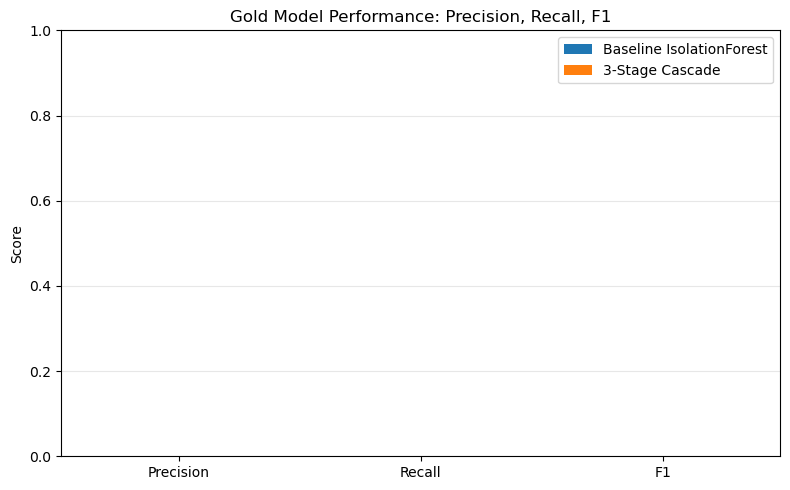

Saved comparison plot to: /workspace/artifacts/gold/pump/pump__gold__comparison__metrics_barplot.png
W&B: logged comparison plot and table.


In [55]:
metrics_to_plot = ["Precision", "Recall", "F1"]

models = comparison_table["Model"].tolist()
n_models = len(models)
n_metrics = len(metrics_to_plot)

values = []
for metric in metrics_to_plot:
    values.append(comparison_table[metric].values)

values = np.array(values)  # shape: (n_metrics, n_models)

x = np.arange(n_metrics)  # positions for metrics
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(models):
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, values[:, i], width=width, label=model)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("Gold Model Performance: Precision, Recall, F1")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

# Save the bar chart as an artifact
plot_path = GOLD_ARTIFACTS_PATH / "pump__gold__comparison__metrics_barplot.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved comparison plot to: {plot_path}")

# Check for wandb
if "wandb_run" in globals() and wandb_run is not None:
    try:
        import wandb

        # Log the PNG as an image
        wandb_run.log({
            "gold/comparison_plot": wandb.Image(str(plot_path))
        })

        # Also log the comparison table as a W&B Table
        wandb_run.log({
            "gold/model_comparison_table": wandb.Table(dataframe=comparison_table)
        })

        print("W&B: logged comparison plot and table.")
    except Exception as e:
        print(f"W&B logging skipped due to error: {e}")



In [ ]:
comparison_table.to_csv(BASELINE_VS_CASCADE_PATH, index=False)
save_json(comparison_summary, BASELINE_VS_CASCADE_SUMMARY_PATH)

wandb.save(str(BASELINE_VS_CASCADE_PATH))
wandb.save(str(BASELINE_VS_CASCADE_SUMMARY_PATH))

ledger.add(
    kind="step",
    step="save_comparison_outputs",
    message="Saved final baseline versus cascade comparison outputs.",
    data={
        "comparison_csv": str(BASELINE_VS_CASCADE_PATH),
        "comparison_summary_json": str(BASELINE_VS_CASCADE_SUMMARY_PATH),
        "comparison_rows": int(len(comparison_table)),
    },
    logger=logger,
)

In [ ]:
ledger.add(
    kind="step",
    step="finalize_comparison",
    message="Gold comparison notebook complete.",
    data={
        "comparison_csv": str(BASELINE_VS_CASCADE_PATH),
        "comparison_summary_json": str(BASELINE_VS_CASCADE_SUMMARY_PATH),
        "comparison_summary": comparison_summary,
    },
    logger=logger,
)

comparison_ledger_path = GOLD_ARTIFACTS_PATH / GOLD_COMPARISION_LEDGER_FILE_NAME
ledger.write_json(comparison_ledger_path)

wandb.save(str(comparison_ledger_path))
wandb_run.finish()